# Chicago TNP Trips — EDA

Exploratory data analysis of Chicago Transportation Network Provider (rideshare) trips.
Data: monthly 100k samples for 2022–2024.
Goal: validate the dataset for the dynamic-pricing and simulator-validation projects.

In [1]:
# Install dependencies 
%pip install -q pandas matplotlib requests


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load data

In [2]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/Users/acu/文稿文件/个人文件/实习/MatrixOrigin_20260615-20260915/Week 1/Chicago_Taxi"

# Load all monthly CSV samples and combine into one DataFrame
csvs = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
df = pd.concat((pd.read_csv(f) for f in csvs), ignore_index=True)

# Normalize column names to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(r"[ .]+", "_", regex=True)

print("files:", len(csvs), "| shape:", df.shape)
df.head()

files: 36 | shape: (3600000, 21)


,trip_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,...,additional_charges,trip_total,shared_trip_authorized,trips_pooled,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,84d7e438ea62127fe90247090c32e4fbf7d58542,2022-01-01T02:15:00.000,2022-01-01T02:15:00.000,321.0,1.1300,1.703184e+10,1.703108e+10,32.0,8.0,17.5,...,1.02,21.52,False,1,41.880994,-87.632746,POINT (-87.6327464887 41.8809944707),41.892508,-87.626215,POINT (-87.6262149064 41.8925077809)
1,850c787c90d5d043468663336adcc0aa401593dc,2022-01-01T02:15:00.000,2022-01-01T02:30:00.000,978.0,4.0700,1.703106e+10,1.703108e+10,6.0,8.0,45.0,...,1.02,46.02,False,1,41.936159,-87.661265,POINT (-87.6612652184 41.936159071),41.892508,-87.626215,POINT (-87.6262149064 41.8925077809)
2,8511f176b6df9e18202a61f31d19372b19e1acc5,2022-01-01T02:15:00.000,2022-01-01T02:30:00.000,939.0,4.0192,1.703124e+10,1.703116e+10,24.0,16.0,42.5,...,2.86,45.36,False,1,41.906771,-87.681025,POINT (-87.6810252307 41.9067713317),41.955772,-87.701213,POINT (-87.7012131039 41.9557717866)
3,8513b046440d1465a0f577451851488a8be06812,2022-01-01T02:15:00.000,2022-01-01T02:30:00.000,762.0,4.4018,1.703116e+10,1.703107e+10,16.0,7.0,22.5,...,2.92,25.42,False,1,41.958798,-87.738394,POINT (-87.7383939059 41.9587978628),41.928763,-87.665677,POINT (-87.665676837 41.9287630064)
4,851a4152157d53e86d76b70dddf40626e5c54add,2022-01-01T02:15:00.000,2022-01-01T02:30:00.000,587.0,4.2239,1.703108e+10,1.703106e+10,8.0,6.0,40.0,...,2.83,42.83,False,1,41.892073,-87.628874,POINT (-87.6288741572 41.8920726347),41.949829,-87.643965,POINT (-87.6439653703 41.949829346)


## 2. Columns and dtypes

In [3]:
# Column names and data types
df.dtypes

trip_id                           str
trip_start_timestamp              str
trip_end_timestamp                str
trip_seconds                  float64
trip_miles                    float64
pickup_census_tract           float64
dropoff_census_tract          float64
pickup_community_area         float64
dropoff_community_area        float64
fare                          float64
tip                           float64
additional_charges            float64
trip_total                    float64
shared_trip_authorized           bool
trips_pooled                    int64
pickup_centroid_latitude      float64
pickup_centroid_longitude     float64
pickup_centroid_location          str
dropoff_centroid_latitude     float64
dropoff_centroid_longitude    float64
dropoff_centroid_location         str
dtype: object

## 3. Time coverage

Each month is sampled to exactly 100k rows, so absolute trip volume is **not** preserved here.
True monthly volume is recovered later via the portal API (section 12).

In [4]:
# Parse pickup timestamp and count rows per month
df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"])
df.groupby(df["trip_start_timestamp"].dt.to_period("M")).size()

trip_start_timestamp
2022-01    100000
2022-02    100000
2022-03    100000
2022-04    100000
2022-05    100000
2022-06    100000
2022-07    100000
2022-08    100000
2022-09    100000
2022-10    100000
2022-11    100000
2022-12    100000
2023-01    100000
2023-02    100000
2023-03    100000
2023-04    100000
2023-05    100000
2023-06    100000
2023-07    100000
2023-08    100000
2023-09    100000
2023-10    100000
2023-11    100000
2023-12    100000
2024-01    100000
2024-02    100000
2024-03    100000
2024-04    100000
2024-05    100000
2024-06    100000
2024-07    100000
2024-08    100000
2024-09    100000
2024-10    100000
2024-11    100000
2024-12    100000
Freq: M, dtype: int64

## 4. Missing values

In [5]:
# Missing rate per column (%)
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

pickup_census_tract           35.94
dropoff_census_tract          35.94
pickup_community_area          0.33
dropoff_community_area         0.29
tip                            0.24
fare                           0.24
additional_charges             0.24
trip_total                     0.24
trips_pooled                   0.00
dropoff_centroid_longitude     0.00
dropoff_centroid_latitude      0.00
pickup_centroid_location       0.00
pickup_centroid_longitude      0.00
pickup_centroid_latitude       0.00
trip_id                        0.00
shared_trip_authorized         0.00
trip_start_timestamp           0.00
trip_miles                     0.00
trip_seconds                   0.00
trip_end_timestamp             0.00
dropoff_centroid_location      0.00
dtype: float64

## 5. Numeric summary

In [6]:
num_cols = ["fare", "tip", "additional_charges", "trip_total", "trip_seconds", "trip_miles"]
df[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fare,3591221.0,15.61,11.15,0.0,7.50,12.50,20.00,570.00
tip,3591221.0,1.10,2.51,0.0,0.00,0.00,0.00,100.00
additional_charges,3591221.0,4.16,3.82,0.0,2.22,3.22,4.89,302.61
trip_total,3591221.0,20.86,14.30,0.0,11.78,16.37,24.48,589.07
trip_seconds,3599900.0,967.53,680.74,0.0,497.00,792.00,1243.00,35283.00
trip_miles,3599996.0,5.36,5.14,0.0,1.75,3.44,7.00,488.08


## 6. Data quality notes

- `fare`, `trip_total`, `trip_miles`, `trip_seconds` have a min of 0 -> cancelled / invalid trips to filter out.
- Long tails: trip_miles up to ~488, trip_seconds up to ~9.8h -> cap extreme outliers.
- `tip` is mostly 0 (TNP tips are largely unrecorded), so it is a weak price signal.
- Privacy rounding: fares are rounded to the nearest \$2.50 and tips to \$1.00; timestamps to 15 min.
  The 7.50 / 12.50 / 20.00 fare quartiles reflect the \$2.50 step. The finer price signal lives in `additional_charges`.

## 7. Cleaning

In [7]:
# Remove invalid rows and extreme outliers
before = len(df)
df_clean = df.dropna(subset=["fare", "trip_total"]).copy()
df_clean = df_clean[(df_clean["fare"] > 0) & (df_clean["trip_miles"] > 0) & (df_clean["trip_seconds"] > 0)]
df_clean = df_clean[(df_clean["trip_miles"] < 100) & (df_clean["trip_seconds"] < 3 * 3600)]
after = len(df_clean)
print(f"before: {before:,} | after: {after:,} | removed: {before - after:,} ({(before - after) / before:.2%})")

before: 3,600,000 | after: 3,582,404 | removed: 17,596 (0.49%)


## 8. Time features

Features for the pricing/demand models. Night and rush windows are demand-pattern
heuristics (TNP fares are not metered like taxis).

In [8]:
# Build time-based features
dt = df_clean["trip_start_timestamp"].dt
df_clean["hour"] = dt.hour
df_clean["dow"] = dt.dayofweek  # 0=Mon ... 6=Sun
df_clean["is_weekend"] = (dt.dayofweek >= 5).astype("int8")
df_clean["is_night"] = ((dt.hour >= 22) | (dt.hour < 6)).astype("int8")
df_clean["is_rush"] = ((dt.dayofweek < 5) &
                       (((dt.hour >= 7) & (dt.hour < 10)) | ((dt.hour >= 16) & (dt.hour < 19)))).astype("int8")
df_clean[["hour", "dow", "is_weekend", "is_night", "is_rush"]].head()

,hour,dow,is_weekend,is_night,is_rush
0,2,5,1,1,0
1,2,5,1,1,0
2,2,5,1,1,0
3,2,5,1,1,0
4,2,5,1,1,0


## 9. Demand by time

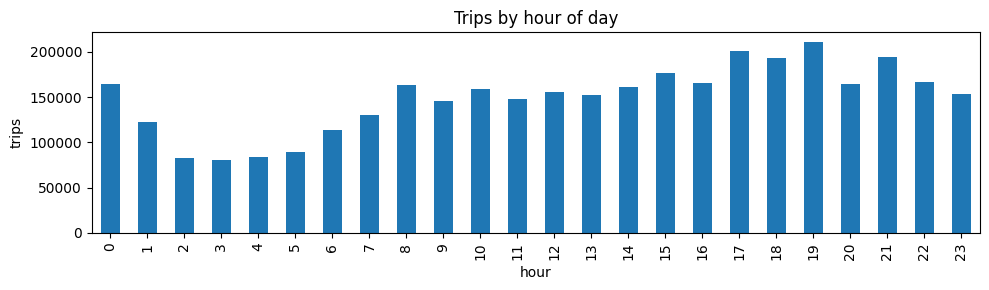

In [9]:
# Trips by hour of day
df_clean.groupby("hour").size().plot(kind="bar", figsize=(10, 3), title="Trips by hour of day")
plt.xlabel("hour"); plt.ylabel("trips"); plt.tight_layout(); plt.show()

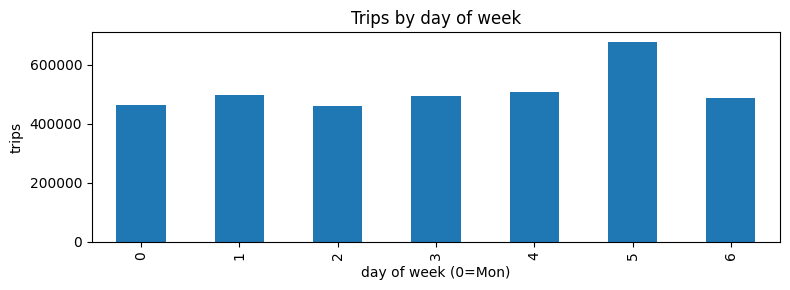

In [10]:
# Trips by day of week (0=Mon)
df_clean.groupby("dow").size().plot(kind="bar", figsize=(8, 3), title="Trips by day of week")
plt.xlabel("day of week (0=Mon)"); plt.ylabel("trips"); plt.tight_layout(); plt.show()

## 10. Fare distribution

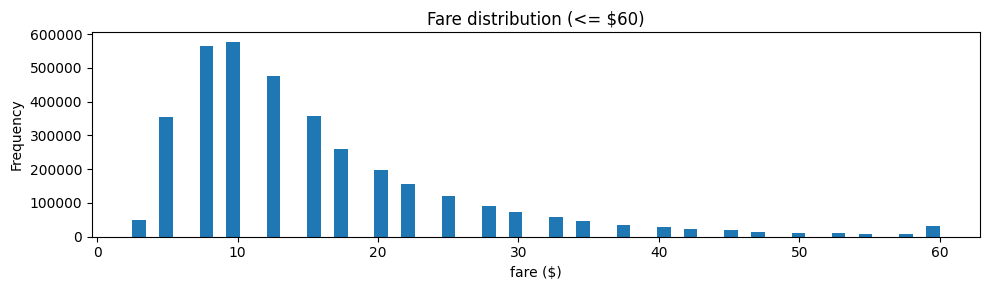

In [11]:
# Fare distribution (clipped at $60; note the $2.50 rounding steps)
df_clean["fare"].clip(upper=60).plot(kind="hist", bins=60, figsize=(10, 3), title="Fare distribution (<= $60)")
plt.xlabel("fare ($)"); plt.tight_layout(); plt.show()

## 11. Price structure: base vs variable

`fare` scales with distance (base proxy); `additional_charges` carries surge/fees (variable proxy).
Below: same-month, cross-year median fare, controlled by distance bucket — the comparison the project asks for.

In [12]:
# Base vs variable proxies
df_clean["fare_per_mile"] = df_clean["fare"] / df_clean["trip_miles"]
df_clean["year"] = df_clean["trip_start_timestamp"].dt.year
df_clean["month"] = df_clean["trip_start_timestamp"].dt.month
df_clean["mile_bin"] = pd.cut(df_clean["trip_miles"], bins=[0, 2, 5, 10, 20, 100])

# Same-month (January) cross-year comparison, holding distance roughly fixed
jan = df_clean[df_clean["month"] == 1]
jan.pivot_table(values="fare", index="mile_bin", columns="year", aggfunc="median", observed=True)

year,2022,2023,2024
mile_bin,,,
"(0, 2]",5.0,7.5,7.5
"(2, 5]",10.0,10.0,10.0
"(5, 10]",15.0,15.0,15.0
"(10, 20]",22.5,22.5,25.0
"(20, 100]",32.5,32.5,35.0


## 12. Population size & sampling ratio (Socrata API)

The 100k/month sampling removes absolute volume. Query the portal for true monthly
counts and recover the sampling ratio. Requires internet.

In [13]:
import requests

# Chicago Data Portal (Socrata) dataset ids
TNP_2018_2022 = "m6dm-c72p"
TNP_2023_2024 = "n26f-ihde"

def monthly_population(dataset_id):
    url = f"https://data.cityofchicago.org/resource/{dataset_id}.json"
    params = {
        "$select": "date_extract_y(trip_start_timestamp) AS yr, "
                   "date_extract_m(trip_start_timestamp) AS mo, count(*) AS n",
        "$group": "yr, mo", "$order": "yr, mo", "$limit": 5000,
    }
    out = pd.DataFrame(requests.get(url, params=params).json())
    return out.astype({"yr": int, "mo": int, "n": int})

pop = pd.concat([monthly_population(TNP_2018_2022), monthly_population(TNP_2023_2024)], ignore_index=True)
pop = pop[pop["yr"].between(2022, 2024)].reset_index(drop=True)
pop.head(12)

,yr,mo,n
0,2022,1,4704329
1,2022,2,4718808
2,2022,3,5837599
3,2022,4,5626360
4,2022,5,5802374
5,2022,6,5755339
6,2022,7,6078292
7,2022,8,5848933
8,2022,9,5821504
9,2022,10,6643944


In [14]:
# Sampling ratio = sample size (100k) / true monthly population
pop["sample_n"] = 100_000
pop["sampling_ratio"] = (pop["sample_n"] / pop["n"]).round(4)
pop[["yr", "mo", "n", "sampling_ratio"]]

,yr,mo,n,sampling_ratio
0,2022,1,4704329,0.0213
1,2022,2,4718808,0.0212
2,2022,3,5837599,0.0171
3,2022,4,5626360,0.0178
4,2022,5,5802374,0.0172
5,2022,6,5755339,0.0174
6,2022,7,6078292,0.0165
7,2022,8,5848933,0.0171
8,2022,9,5821504,0.0172
9,2022,10,6643944,0.0151


# Load Data into Matrix One + H3 Transformation

## 1. H3 Transformation

In [16]:
%pip install -q pandas pyarrow h3 pymysql


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os, glob
import pandas as pd

DATA_DIR = "/Users/acu/文稿文件/个人文件/实习/MatrixOrigin_20260615-20260915/Week 1/Chicago_Taxi"

csvs = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
df = pd.concat((pd.read_csv(f) for f in csvs), ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(r"[ .]+", "_", regex=True)
df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"])
df["trip_end_timestamp"] = pd.to_datetime(df["trip_end_timestamp"])

# Drop invalid rows and extreme outliers
df = df[(df["fare"] > 0) & (df["trip_miles"] > 0) & (df["trip_seconds"] > 0)]
df = df[(df["trip_miles"] < 100) & (df["trip_seconds"] < 3 * 3600)]
print("rows after cleaning:", len(df))

rows after cleaning: 3582404


In [23]:
print(db[["pickup_centroid_latitude", "pickup_centroid_longitude"]].drop_duplicates().shape[0])

877


In [25]:
import h3

keep = [
    "trip_id", "trip_start_timestamp", "trip_end_timestamp",
    "trip_seconds", "trip_miles",
    "pickup_community_area", "dropoff_community_area",
    "fare", "tip", "additional_charges", "trip_total",
    "shared_trip_authorized", "trips_pooled",
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "dropoff_centroid_latitude", "dropoff_centroid_longitude",
]
db = df[keep].dropna().copy()
db["shared_trip_authorized"] = (
    db["shared_trip_authorized"].astype(str).str.lower().map({"true": 1, "false": 0}).astype("int8")
)
for c in ["pickup_community_area", "dropoff_community_area", "trips_pooled"]:
    db[c] = db[c].astype(int)

# H3 computed on unique centroids only (few hundred), then merged back -> fast
RES = 9
for side in ["pickup", "dropoff"]:
    la, lo = f"{side}_centroid_latitude", f"{side}_centroid_longitude"
    uniq = db[[la, lo]].drop_duplicates().copy()
    uniq[f"{side}_h3"] = [h3.latlng_to_cell(a, o, RES) for a, o in zip(uniq[la], uniq[lo])]
    db = db.merge(uniq, on=[la, lo], how="left")
    db[f"{side}_h3_id"] = db[f"{side}_h3"].apply(h3.str_to_int)

print("distinct pickup H3 cells:", db["pickup_h3"].nunique())  # only a few hundred -> tract-level

# Fix column order to match the CREATE TABLE below
final_cols = keep + ["pickup_h3", "pickup_h3_id", "dropoff_h3", "dropoff_h3_id"]
db = db[final_cols]
print("rows to load:", len(db))

distinct pickup H3 cells: 856
rows to load: 3560474


In [26]:
db.to_parquet("chicago_tnp_clean.parquet", index=False)
db.to_csv("chicago_tnp_clean.csv", index=False)

## 2. Import to Data Base

In [28]:
import pymysql

conn = pymysql.connect(
    host="127.0.0.1", port=6001,
    user="root", password="111",   # MatrixOne default creds; change if you customized
    local_infile=True,             # required for LOAD DATA LOCAL INFILE
)
cur = conn.cursor()

cur.execute("CREATE DATABASE IF NOT EXISTS chicago_tnp")
conn.commit()                      # MatrixOne needs an explicit commit after DDL
cur.execute("USE chicago_tnp")

cur.execute("""
CREATE TABLE IF NOT EXISTS trips (
    trip_id                    VARCHAR(64),
    trip_start_timestamp       DATETIME,
    trip_end_timestamp         DATETIME,
    trip_seconds               INT,
    trip_miles                 DOUBLE,
    pickup_community_area      INT,
    dropoff_community_area     INT,
    fare                       DECIMAL(10,2),
    tip                        DECIMAL(10,2),
    additional_charges         DECIMAL(10,2),
    trip_total                 DECIMAL(10,2),
    shared_trip_authorized     TINYINT,
    trips_pooled               INT,
    pickup_centroid_latitude   DOUBLE,
    pickup_centroid_longitude  DOUBLE,
    dropoff_centroid_latitude  DOUBLE,
    dropoff_centroid_longitude DOUBLE,
    pickup_h3                  VARCHAR(16),
    pickup_h3_id               BIGINT,
    dropoff_h3                 VARCHAR(16),
    dropoff_h3_id              BIGINT
)
""")
conn.commit()

In [29]:
import os
csv_path = os.path.abspath("chicago_tnp_clean.csv")

cur.execute(f"""
LOAD DATA LOCAL INFILE '{csv_path}'
INTO TABLE trips
FIELDS TERMINATED BY ',' ENCLOSED BY '"'
LINES TERMINATED BY '\\n'
IGNORE 1 LINES
""")
conn.commit()

cur.execute("SELECT COUNT(*) FROM trips")
print("row count:", cur.fetchone()[0])
cur.execute("SELECT trip_start_timestamp, fare, pickup_h3, pickup_community_area FROM trips LIMIT 5")
for row in cur.fetchall():
    print(row)
cur.close(); conn.close()

row count: 3560474
(datetime.datetime(2024, 9, 4, 10, 0), Decimal('10.00'), '892664c8d6bffff', 30)
(datetime.datetime(2024, 9, 10, 0, 0), Decimal('7.50'), '892664c8cabffff', 29)
(datetime.datetime(2024, 9, 19, 16, 0), Decimal('25.00'), '892664c1b0bffff', 33)
(datetime.datetime(2024, 9, 25, 20, 0), Decimal('10.00'), '892664c114fffff', 7)
(datetime.datetime(2024, 9, 2, 11, 0), Decimal('30.00'), '892664c1e0fffff', 8)
